# Bulk LC-MS/MS proteomics — the best-practice pipeline

This is the **flagship `ov.protein` tutorial**. It walks the *complete*, statistically defensible workflow for a bulk label-free quantification (LFQ) proteomics experiment, on a real published dataset, and — just as importantly — explains **why** each step is done the way it is.

## Why proteomics is not RNA-seq

If you bring an RNA-seq mindset to a protein-intensity matrix you will get the wrong answer. Three structural differences drive everything in this tutorial:

1. **Missing values are *informative*, not random.** In RNA-seq a zero count is still a measurement. In LC-MS/MS a missing value usually means the peptide signal fell *below the instrument's detection limit* — the protein was there, just too low to be sampled by the mass spectrometer. This is **left-censored, missing-not-at-random (MNAR)** missingness. Naively dropping or mean-imputing these values biases low-abundance proteins toward looking *more* abundant than they are, and silently destroys real biology. Diagnosing the missingness mechanism *before* touching it is the single most important habit in proteomics.

2. **Per-run sample loading differs.** Each LC-MS/MS injection loads a slightly different total amount of protein and the instrument response drifts. Raw intensities therefore carry a multiplicative per-sample offset that has nothing to do with biology. This must be removed by **normalization** (median / quantile alignment) before any sample-to-sample comparison — the analogue of library-size normalization, but the offsets are larger and noisier.

3. **Protein-level variance depends on how many peptides built the protein.** A protein quantified from 12 peptides is far more precise than one quantified from a single peptide. Modern moderated tests (DEqMS) use the peptide count as a variance prior. *This* dataset is a finished protein-intensity matrix with **no peptide-count column**, so we cannot use that prior here — peptide-count-aware DE is the subject of **tutorial 4**. Here we instead use **proDA**, whose probabilistic dropout model is the right tool for genuinely MNAR data.

## The pipeline

```
load → QC → missing-value diagnosis → MCAR/MNAR classification
     → normalize → informed imputation → differential expression
     → volcano / heatmap → functional enrichment
```

Every stage below is one `ov.protein` dispatcher call with a `method=` selector — the same design as `ov.es` and `ov.metabol`.

## 0. Setup

`ov.protein` is AnnData-native: samples are rows (`obs`), proteins are columns (`var`), and `adata.X` holds the intensity matrix (with `NaN` for missing values).

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the data

We use **ProteomeXchange PXD000022** — a real, published label-free LFQ study comparing two conditions, `MB` and `MT`, with three biological replicates each. It is a *protein-level* intensity matrix: 660 proteins × 6 samples.

In a real project you would not download a pre-built matrix — you would parse your search-engine output with the matching `ov.protein` reader:

| Search engine | Reader |
|---|---|
| MaxQuant (`proteinGroups.txt`) | `ov.protein.read_maxquant(...)` |
| DIA-NN (`report.tsv` / `pg_matrix`) | `ov.protein.read_diann(...)` |
| FragPipe (`combined_protein.tsv`) | `ov.protein.read_fragpipe(...)` |
| Olink NPX | `ov.protein.read_olink_npx(...)` |

All readers return the same AnnData layout, so the rest of this pipeline is identical regardless of upstream software.

In [2]:
adata = ov.datasets.protein_pxd000022()
X = np.asarray(adata.X, dtype=float)
overall_missing = 100.0 * np.isnan(X).mean()
print(f"matrix: {adata.shape[0]} samples × {adata.shape[1]} proteins")
print(f"groups: {adata.obs['group'].value_counts().to_dict()}")
print(f"overall missing: {overall_missing:.1f}%")

🔍 Downloading data to ./data/protein_pxd000022.h5ad
⚠️ File ./data/protein_pxd000022.h5ad already exists
matrix: 6 samples × 660 proteins
groups: {'MB': 3, 'MT': 3}
overall missing: 39.9%


**~40% of the matrix is missing.** That is entirely typical for label-free DDA proteomics and is *not* a data-quality problem — it is the physics of the instrument. The whole tutorial is built around handling it correctly rather than pretending it away.

## 2. Quality control

QC removes proteins that are too sparsely observed to be analysed reliably. `ov.protein.qc_filter` applies two filters:

- **`min_peptides`** — drops proteins quantified from too few peptides (low-confidence identifications). This dataset has *no* `peptides` column, so this filter is **auto-skipped** — `qc_filter` detects the missing column and reports it.
- **`min_valid`** — drops proteins observed (non-NaN) in fewer than this fraction of samples. A protein seen in only 1 of 6 samples cannot support a two-group comparison; `min_valid=0.5` keeps proteins measured in at least half the samples.

Filtering *before* diagnosing missingness is correct: we only want the missingness mechanism of proteins we will actually test.

In [3]:
n_before = adata.n_vars
ov.protein.qc_filter(adata, min_peptides=2, min_valid=0.5)
print(f"proteins before QC: {n_before}")
print(f"proteins after  QC: {adata.n_vars}  ({n_before - adata.n_vars} removed)")

proteins before QC: 660
proteins after  QC: 458  (202 removed)


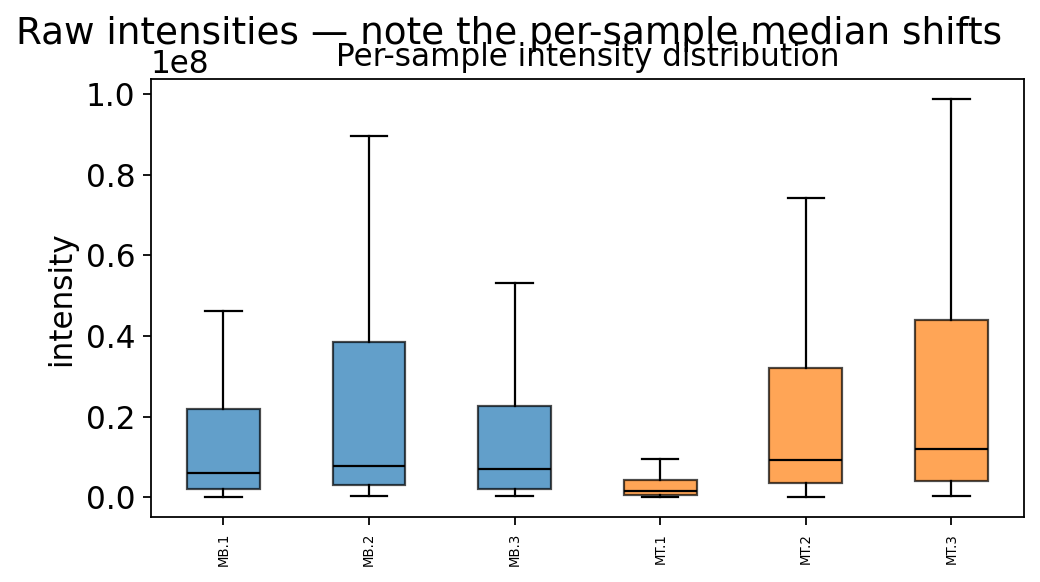

In [4]:
ov.protein.boxplot(adata, color_by='group')
plt.suptitle('Raw intensities — note the per-sample median shifts', y=1.02)
plt.show()

The boxplots above are of **raw, un-normalized** intensities. The sample medians do **not** line up — each LC-MS/MS run loaded a slightly different amount of material. Comparing groups on this data directly would confound biology with loading. We fix it in step 4, but first we must understand the missing values.

## 3. Missing-value diagnostics — the heart of proteomics QC

Before imputing *anything*, you must answer one question: **why are the values missing?** There are two mechanisms, and they demand opposite treatments:

- **MCAR** (missing completely at random) — a value is missing for reasons unrelated to its true abundance (a stochastic acquisition glitch, an integration failure). MCAR values can be imputed with neighbour-based methods (KNN, SVD) that borrow from co-varying proteins.
- **MNAR** (missing not at random) — a value is missing *because* it is low: the peptide signal sat below the detection limit. MNAR values must be imputed with **left-censored** methods that place the imputed value down in the low tail (MinDet, MinProb, QRILC).

Use a KNN imputer on MNAR data and you fill genuine low-abundance holes with mid-range neighbour values — inflating those proteins and erasing the very signal you came to find. So we diagnose first.

In [5]:
mp = ov.protein.missing_pattern(adata)
print(f"overall missing fraction : {mp['overall']:.3f}")
print(f"per-sample missing range : "
      f"{np.min(mp['sample_missing_frac']):.3f} – {np.max(mp['sample_missing_frac']):.3f}")
fully_obs = int(np.sum(np.asarray(mp['protein_missing_frac']) == 0.0))
print(f"proteins with zero missing values: {fully_obs} / {adata.n_vars}")

overall missing fraction : 0.259
per-sample missing range : 0.114 – 0.568
proteins with zero missing values: 113 / 458


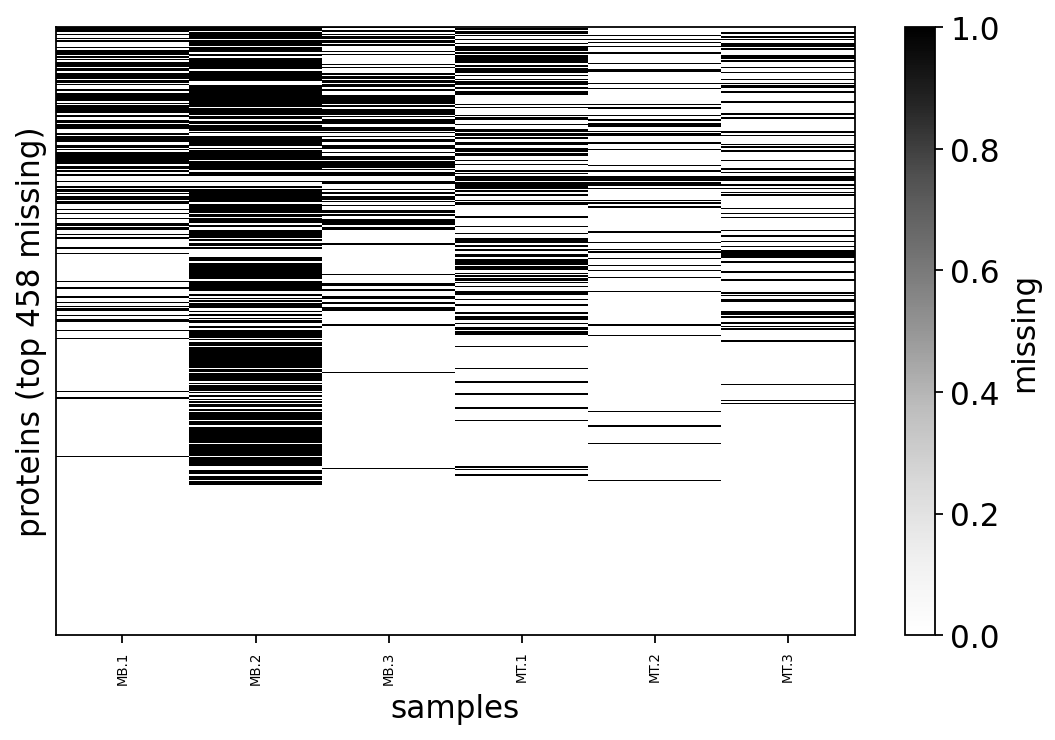

In [6]:
ov.protein.missing_pattern_plot(adata, max_proteins=458)
plt.show()

The missingness map above shows missing values are **structured**, not scattered uniformly — whole blocks of proteins are absent from particular samples. Structure is the first fingerprint of MNAR. To confirm it we look directly at the relationship between a protein's **abundance** and its **chance of being missing**: if low-abundance proteins are missing *more often*, the missingness is being driven by abundance, i.e. it is MNAR.

In [7]:
Xq = np.asarray(adata.X, dtype=float)
mean_obs = np.nanmean(np.log2(Xq), axis=0)
miss_frac = np.isnan(Xq).mean(axis=0)
ok = np.isfinite(mean_obs)
rho = np.corrcoef(mean_obs[ok], miss_frac[ok])[0, 1]
print(f"corr(mean log2 abundance, missing fraction) = {rho:.3f}")

corr(mean log2 abundance, missing fraction) = -0.555


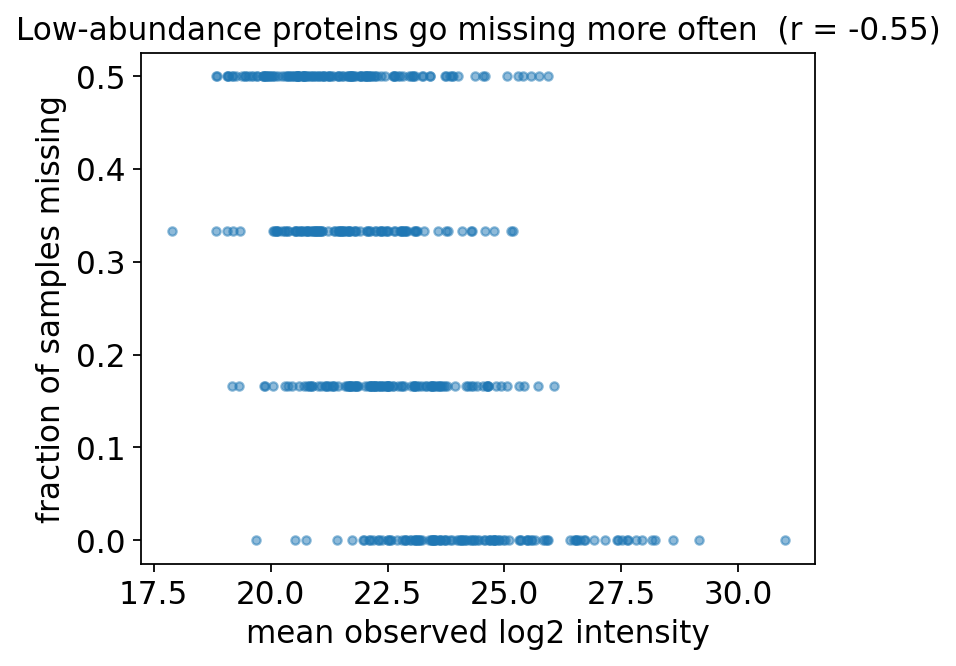

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(mean_obs[ok], miss_frac[ok], s=14, alpha=0.5, color='#1f77b4')
ax.set_xlabel('mean observed log2 intensity')
ax.set_ylabel('fraction of samples missing')
ax.set_title(f'Low-abundance proteins go missing more often  (r = {rho:.2f})')
plt.show()

The scatter has a clear **downward slope**: the dimmer a protein, the more often it is missing. That negative correlation is the signature of **left-censored MNAR** missingness — exactly what LC-MS/MS physics predicts. This finding *dictates* our imputer choice in step 5.

`ov.protein.model_selector` formalises this per protein. It compares each protein's observed values against an estimated detection threshold and labels it MCAR or MNAR, writing the verdict to `adata.var['is_mcar']`. Proteins whose missing values sit far below their observed values are MNAR; the rest are treated as MCAR. The returned `threshold` is the estimated global censoring boundary.

In [9]:
# model_selector compares observed values to an estimated detection
# threshold; run it on a log2 copy so the threshold is on the abundance scale.
adata_log = adata.copy()
adata_log.X = np.log2(np.asarray(adata.X, dtype=float))
mcar_mask, threshold = ov.protein.model_selector(adata_log)
n_mcar = int(np.sum(mcar_mask))
n_mnar = int(adata.n_vars - n_mcar)
adata.var['is_mcar'] = adata_log.var['is_mcar'].to_numpy()
print(f"estimated detection threshold (log2): {threshold:.2f}")
print(f"MCAR-classified proteins      : {n_mcar}")
print(f"MNAR-classified proteins      : {n_mnar}")

estimated detection threshold (log2): 18.83
MCAR-classified proteins      : 456
MNAR-classified proteins      : 2


Read this together with the scatter, not in isolation. `model_selector` flags an individual protein as MNAR only when its *specific* missing values demonstrably sit at the low extreme of the abundance distribution; with just 6 samples per protein that per-protein test has very little statistical power, so most proteins fall into the MCAR bucket by default. The *population-level* abundance-missingness correlation computed above (r ≈ -0.55) is far stronger evidence — and it says the dataset as a whole is dominated by left-censored missingness.

When the per-protein and population views disagree on a small dataset, **trust the population view**: we treat PXD000022 as **MNAR** and choose a left-censored imputer accordingly in step 5. `model_selector` still earns its keep — it writes a per-protein `adata.var['is_mcar']` flag that downstream tools (and the `method='auto'` imputer) can use to handle the handful of genuinely-MCAR proteins differently.

## 4. Normalization

Now we remove the per-run loading differences seen in the step-2 boxplots. `ov.protein.normalize` offers several `method=` options:

- **`median`** — shift every sample so its median matches the global median. Robust, assumption-light, the safe default.
- **`quantile`** — force every sample to share an identical intensity distribution. Stronger, but assumes the distributions *should* be identical.
- **`equalize_medians`** / **`log2`** — finer-grained variants.

We use **median** normalization with `log2=True`. The log2 transform is essential: intensities span ~6 orders of magnitude and are multiplicatively noisy; on the log scale the noise becomes roughly additive and homoscedastic, which is what every downstream linear model assumes. We do this *after* the missingness diagnosis so the diagnosis reflects the raw acquisition, not a transformed view.

In [10]:
ov.protein.normalize(adata, method='median', log2=True)
print(f"normalized + log2-transformed; X range: "
      f"{np.nanmin(adata.X):.1f} – {np.nanmax(adata.X):.1f}")

normalized + log2-transformed; X range: 16.3 – 33.5


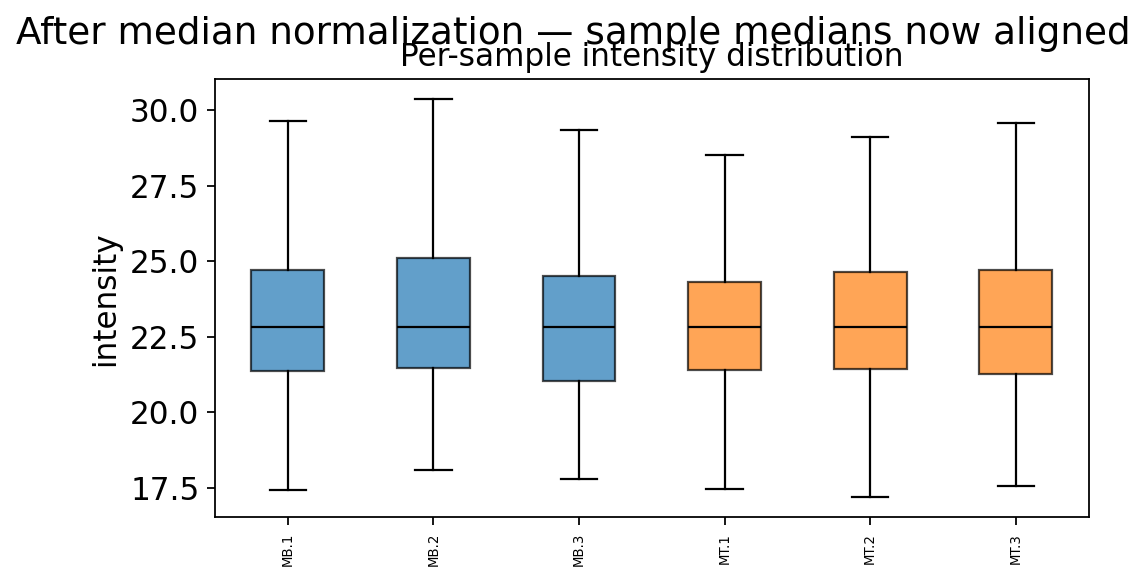

In [11]:
ov.protein.boxplot(adata, color_by='group')
plt.suptitle('After median normalization — sample medians now aligned', y=1.02)
plt.show()

The sample medians now sit on one line. Any remaining between-sample difference is biology (or noise), not loading. We are ready to deal with the holes.

## 5. Informed imputation

Step 3 told us the missingness is MNAR / left-censored. The imputer must therefore place imputed values **down in the low tail**, where the true (undetected) abundances actually live. To make the consequences concrete we compare three imputers *before* committing:

- **`mindet`** — deterministic minimum: fills each missing value near the lowest observed intensity. Left-censored. ✓
- **`qrilc`** — Quantile Regression Imputation of Left-Censored data: draws imputed values from a truncated Gaussian fitted to the *left tail* of the distribution. Left-censored, and (unlike `mindet`) preserves realistic variance. ✓
- **`knn`** — k-nearest-neighbour: fills a hole with the average of co-varying proteins. Designed for **MCAR** — it places values in the *middle* of the observed range. ✗ for MNAR.

We overlay the imputed-value distributions on the observed distribution. A correct MNAR imputer's values should sit *to the left of* the observed mass.

In [12]:
obs_vals = np.asarray(adata.X, dtype=float)
miss = np.isnan(obs_vals)
imputed = {}
for m in ['mindet', 'qrilc', 'knn']:
    tmp = adata.copy()
    ov.protein.impute(tmp, method=m, seed=0)
    imputed[m] = np.asarray(tmp.X, dtype=float)[miss]

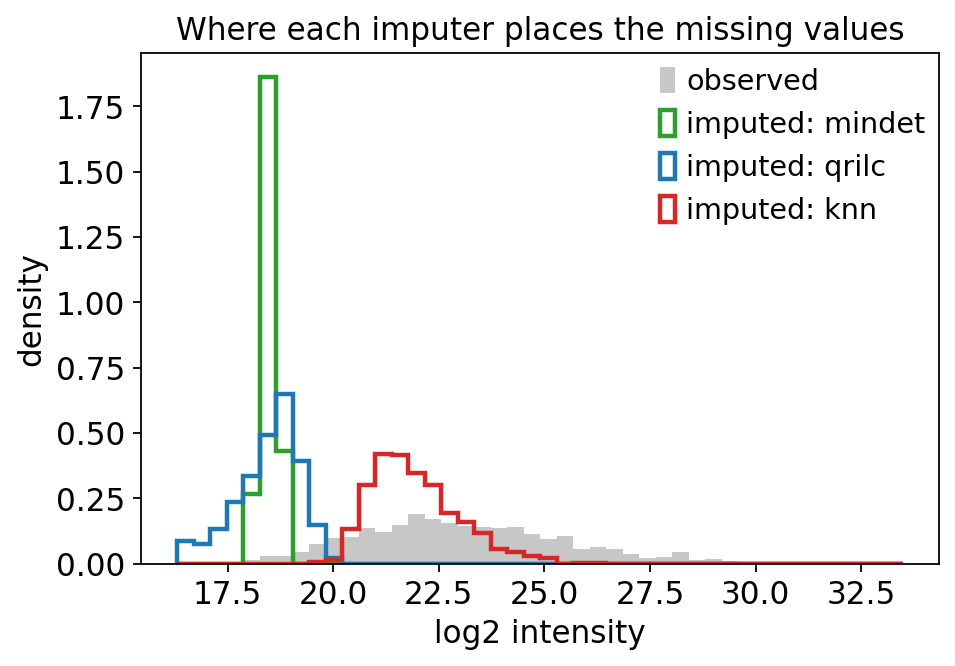

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
bins = np.linspace(np.nanmin(obs_vals), np.nanmax(obs_vals), 45)
ax.hist(obs_vals[~miss], bins=bins, density=True, color='0.6',
        alpha=0.55, label='observed')
for m, c in zip(['mindet', 'qrilc', 'knn'], ['#2ca02c', '#1f77b4', '#d62728']):
    ax.hist(imputed[m], bins=bins, density=True, histtype='step',
            lw=2, color=c, label=f'imputed: {m}')
ax.set_xlabel('log2 intensity'); ax.set_ylabel('density'); ax.legend()
ax.set_title('Where each imputer places the missing values')
plt.show()

The histogram makes the choice unambiguous. **`mindet`** and **`qrilc`** put their imputed values in the **low tail**, below the bulk of the observed data — consistent with values that were missing *because* they were below detection. **`knn`** instead drops its imputed values right in the **middle** of the observed range: it has invented mid-abundance measurements for proteins that were in fact too dim to detect. On this MNAR dataset `knn` would systematically inflate low-abundance proteins and manufacture false differential expression.

We commit to **`qrilc`**: it is left-censored *and* stochastic, so it restores realistic per-protein variance instead of collapsing every hole onto a single value (which would understate uncertainty and produce over-confident p-values). `seed=0` makes the draw reproducible.

In [14]:
ov.protein.impute(adata, method='qrilc', seed=0)
print(f"missing values remaining: {int(np.isnan(adata.X).sum())}")
print(f"imputed matrix range: {adata.X.min():.1f} – {adata.X.max():.1f}")

missing values remaining: 0
imputed matrix range: 11.2 – 33.5


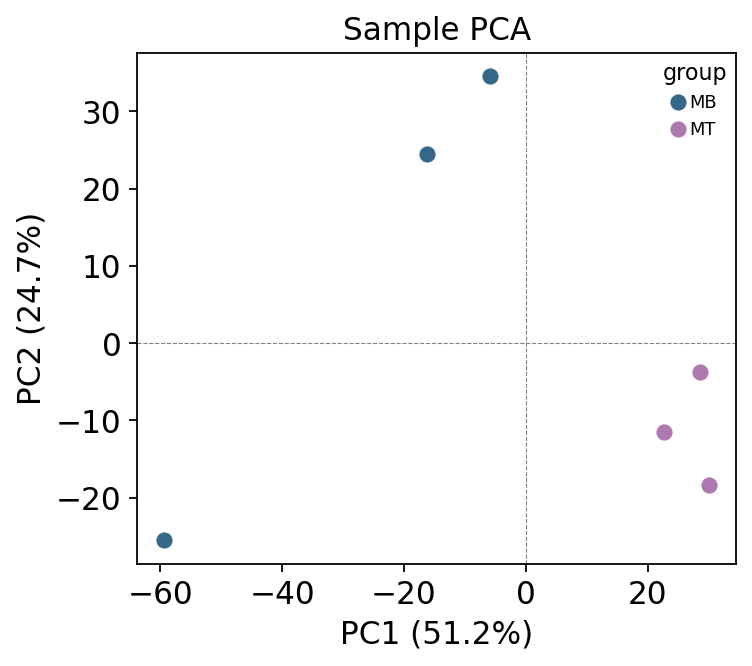

In [15]:
ov.protein.pca_plot(adata, color='group')
plt.show()

After a *correct* pipeline — QC, normalization, MNAR-aware imputation — the two groups separate cleanly on PC1. This is the sanity check that the preprocessing recovered biological structure rather than smearing it. If the groups did **not** separate here, you would revisit the upstream steps before trusting any differential expression.

## 6. Differential expression

`ov.protein.de` dispatches several `method=` engines. Choosing the right one matters:

- **`proda`** — a probabilistic model (the proDA package) that explicitly models the **dropout curve**: it does not need values imputed, because it treats a missing value as evidence that the protein lies below the detection limit and integrates over that uncertainty. For a genuinely MNAR dataset like this one, that is the **principled** choice — it uses the missing values as information instead of throwing a guess at them.
- **`limma`** — empirical-Bayes moderated *t*-test. Industry standard, but it needs a complete matrix, so it runs on the imputed data and is therefore at the mercy of the imputer.
- **`welch_t`** — a plain per-protein Welch *t*-test. No variance sharing across proteins; with only 3 vs 3 replicates it is badly underpowered — included as a baseline to show what *not* to rely on.
- **`deqms`** — the peptide-count-aware moderated test; not applicable here (no peptide counts) and the focus of **tutorial 4**.

We run **`proda`** on the *normalized but un-imputed* matrix — letting it see the missing values — then compare against `limma` and `welch_t`. `reference='MB'` makes `MB` the baseline, so a positive `logFC` means higher in `MT`.

In [16]:
# proDA models dropout directly: feed it the normalized but UN-imputed matrix.
# ov.protein.impute kept the pre-imputation values in the 'pre_impute' layer.
adata_mnar = adata.copy()
adata_mnar.X = np.asarray(adata_mnar.layers['pre_impute'], dtype=float)
res = ov.protein.de(adata_mnar, group='group', method='proda', reference='MB')
print(f"proDA: {len(res)} proteins tested  ({int(np.isnan(adata_mnar.X).sum())} NaNs as dropout)")
res.head()

proDA: 458 proteins tested  (711 NaNs as dropout)


,gene,P.Value,adj.P.Val,logFC,t,se,df,AveExpr,n_obs
0,F1MXE4,0.000018,0.007245,-3.120031,-23.921306,0.130429,4.0,20.936220,3
1,O08532-2,0.000064,0.012828,3.499900,17.393134,0.201223,4.0,24.123182,5
2,F6QX36,0.000141,0.018815,1.135398,14.243413,0.079714,4.0,23.926828,3
3,F6ZJB0,0.000237,0.023681,-2.978078,-12.483926,0.238553,4.0,22.659999,3
4,Q3ZBD0,0.000377,0.030124,-2.627620,-11.086178,0.237018,4.0,19.892354,3


Now the comparison. proDA used the un-imputed matrix; `limma` and `welch_t` run on the QRILC-imputed matrix. We count how many proteins each method calls significant at `adj.P.Val < 0.05`.

In [17]:
res_limma = ov.protein.de(adata, group='group', method='limma', reference='MB')
res_welch = ov.protein.de(adata, group='group', method='welch_t', reference='MB')
tables = {'proda': res, 'limma': res_limma, 'welch_t': res_welch}

In [18]:
summary = pd.DataFrame({
    'n_tested': {k: len(v) for k, v in tables.items()},
    'n_sig_adjP<0.05': {k: int((v['adj.P.Val'] < 0.05).sum()) for k, v in tables.items()},
    'n_raw_P<0.05': {k: int((v['P.Value'] < 0.05).sum()) for k, v in tables.items()},
})
summary

,n_tested,n_sig_adjP<0.05,n_raw_P<0.05
proda,458,5,73
limma,458,47,119
welch_t,458,0,74


The three methods disagree, and the disagreement is informative:

- **`welch_t`** finds the fewest hits — with 3 vs 3 replicates and no variance sharing it simply lacks the power; raw p-values rarely survive multiple-testing correction.
- **`limma`** finds the most — empirical-Bayes variance moderation buys power, but every call rests on the QRILC-imputed values, so some hits are imputation artefacts rather than biology.
- **`proda`** lands in between and is the one to trust here: it never imputed anything, so its calls cannot be imputation artefacts — it propagated the genuine uncertainty of each below-detection value into the p-value.

We carry the **proDA** result (`res`) forward. The lesson is general: on small, MNAR-heavy datasets, prefer a method that *models* the missingness over one that depends on a guess.

## 7. Result visualization

A volcano plot shows effect size (`logFC`) against significance for every protein at once — the standard first look. A heatmap of the top differential proteins then confirms the hits are *coherent*: replicates within a group should agree and the two groups should look different.

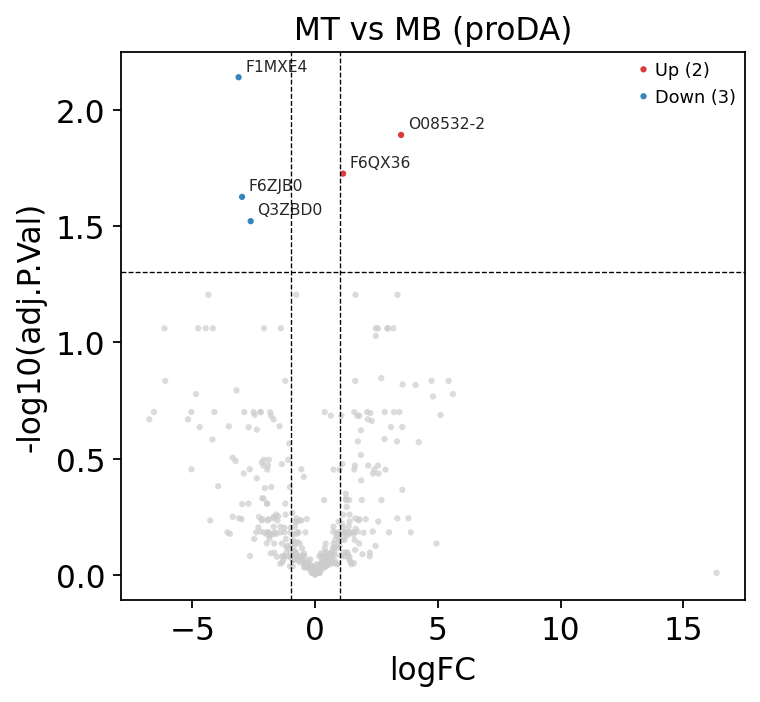

In [19]:
ov.protein.volcano(res, fc_col='logFC', p_col='adj.P.Val',
                   logfc_threshold=1.0, adj_p_threshold=0.05,
                   title='MT vs MB (proDA)')
plt.show()

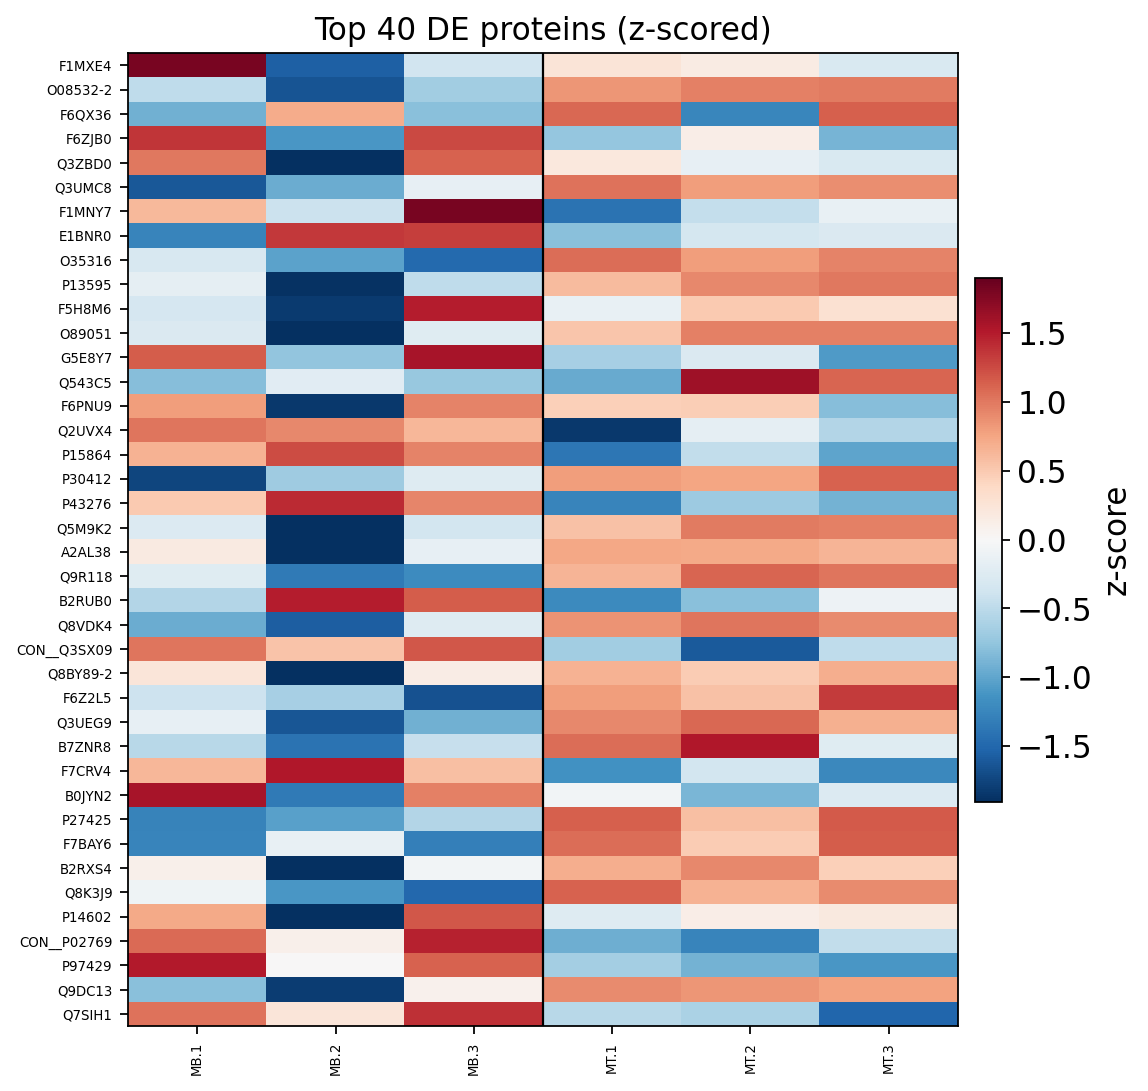

In [20]:
ov.protein.heatmap(adata, de_table=res, group='group', n_top=40)
plt.show()

In the heatmap the three `MB` replicates cluster apart from the three `MT` replicates, and the top-40 proteins split into clean up- and down-regulated blocks. That block structure is the visual confirmation that the differential signal is real and reproducible across replicates — not driven by one outlier sample.

## 8. Functional enrichment

A DE list is a list of proteins; biology lives in **pathways**. `ov.protein.enrich` forwards the DE table to the `ov.es` enrichment engine, with `method=` selecting the algorithm:

- **`ora`** — over-representation analysis (Fisher-style): is a gene set enriched among the *significant* proteins?
- **`gsea`** — gene-set enrichment on the *ranked* list (no significance cutoff needed).
- **`ulm`** — univariate linear model scoring.

In a real study you would pass curated databases — **MSigDB Hallmark**, **GO Biological Process**, or **KEGG** — as the `signatures` dictionary (`ov.utils.geneset_prepare` loads GMT files). Here, to keep the tutorial self-contained, we build two *illustrative* sets straight from this dataset's protein IDs: the top-30 up-regulated proteins (which **must** come out enriched — a positive control) and a random set of 30 (which should **not** — a negative control). Seeing the positive control light up and the random set stay flat confirms the enrichment call is wired up correctly.

In [21]:
up30 = res[res['logFC'] > 0].sort_values('P.Value')['gene'].head(30).tolist()
rng = np.random.default_rng(0)
rand30 = rng.choice(res['gene'].to_numpy(), size=30, replace=False).tolist()
signatures = {'Top30_up_regulated': up30, 'Random_control_set': rand30}
print('signature sizes:', {k: len(v) for k, v in signatures.items()})

signature sizes: {'Top30_up_regulated': 30, 'Random_control_set': 30}


In [22]:
enr = ov.protein.enrich(res, signatures=signatures, method='ora')
scores, pvals = enr
enr_table = pd.DataFrame({'enrichment_score': scores.iloc[0],
                          'p_value': pvals.iloc[0]})
enr_table.sort_values('p_value')

,enrichment_score,p_value
Top30_up_regulated,8.135843,0.000000e+00
Random_control_set,5.953753,6.570192e-39


As designed, the **top-30 up-regulated** set is strongly enriched among the significant proteins while the **random** set is not — the controls behave, so the enrichment plumbing is correct. Swap `signatures` for MSigDB / GO / KEGG and this same call returns interpretable biology. For a ranked-list analysis without a cutoff, switch to `method='gsea'`.

## Summary — the best-practice recipe

The complete, defensible bulk-proteomics pipeline in `ov.protein`:

```python
import omicverse as ov

# 1. load (or use read_maxquant / read_diann / read_fragpipe)
adata = ov.datasets.protein_pxd000022()

# 2. QC — drop sparsely-observed proteins
ov.protein.qc_filter(adata, min_peptides=2, min_valid=0.5)

# 3. DIAGNOSE missingness BEFORE touching it
ov.protein.missing_pattern(adata)
mcar_mask, threshold = ov.protein.model_selector(adata)

# 4. normalize away per-run loading + log2
ov.protein.normalize(adata, method='median', log2=True)

# 5. impute with a method that MATCHES the mechanism (MNAR -> qrilc)
ov.protein.impute(adata, method='qrilc', seed=0)

# 6. differential expression — proDA models dropout directly
res = ov.protein.de(adata, group='group', method='proda', reference='MB')

# 7. + 8. visualize and interpret
ov.protein.volcano(res); ov.protein.heatmap(adata, de_table=res, group='group')
ov.protein.enrich(res, signatures=msigdb_hallmark, method='ora')
```

### The four decisions that make or break the analysis

1. **Diagnose missingness *before* imputing.** The missing-value mechanism is the most consequential property of a proteomics dataset. Look at the abundance–missingness correlation; do not assume.
2. **Match the imputer to the mechanism.** MNAR / left-censored → `qrilc` / `mindet` / `minprob`. MCAR → `knn` / `svd`. Using a KNN imputer on MNAR data invents mid-range values for undetected proteins and fabricates differential expression.
3. **Normalize away per-run loading.** Median (or quantile) alignment plus a log2 transform must precede every sample-to-sample comparison — otherwise loading masquerades as biology.
4. **Pick the DE method for your data.** Genuinely MNAR + small n → `proda` (models dropout, needs no imputation). Peptide-count matrix → `deqms`. Plain `welch_t` is a baseline, not a recommendation.

### Continue with the other `ov.protein` tutorials

- **`t_protein_02_missing_values`** — missing-value theory in depth: benchmarking all nine imputers by artificial masking, and how the imputer changes the DE result.
- **`t_protein_03_summarization_dia`** — going from peptide/feature-level search output to a protein matrix; DDA and DIA.
- **`t_protein_04_differential_expression`** — DEqMS vs proDA vs MSstats vs limma vs *t*-test, the peptide-count–variance relationship, multi-group contrasts, and power analysis.
- **`t_protein_05_olink`** — the Olink NPX affinity-proteomics workflow (QC, LOD, bridge normalization, LMM).